# Analiza Rynku Nieruchomości i Przewidywanie Cen
**Cel:** Stworzenie modelu Machine Learning, który wyceni mieszkanie na podstawie parametrów oraz wskaże niedowartościowane oferty -> okazje.

In [1]:
import os

# Konfiguracja API Kaggle
os.environ['KAGGLE_USERNAME'] = "sikoraa36" 
os.environ['KAGGLE_KEY'] = "KLUCZ_API" 
# !kaggle datasets download -d krzysztofjamroz/apartment-prices-in-poland --unzip

## 1. Integracja Danych
Dane pochodzą z wielu plików CSV - miesięczne raporty. Scalamy je w jeden DataFrame, aby mieć pełny obraz rynku.

In [2]:
import pandas as pd
import glob

# wszystkie pliki ze sprzedażą (zaczynają się od "apartments_pl_") Ignorujemy pliki "rent" (wynajem)
files = sorted(glob.glob("apartments_pl_*.csv"))

print(f"Znaleziono {len(files)} plików do połączenia.")

dfs = []
for filename in files:
    temp_df = pd.read_csv(filename)
    # Wyciągamy rok i miesiąc z nazwy pliku, żeby wiedzieć kiedy była oferta
    # np. z 'apartments_pl_2023_09.csv' robimy '2023_09'
    month_id = filename.replace("apartments_pl_", "").replace(".csv", "")
    temp_df['year_month'] = month_id 
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

print(f"Łączna liczba ofert w Twojej bazie: {df.shape[0]}")

# Tworzymy kolumnę price_per_m2 (Cena całkowita / Metraż)
df['price_per_m2'] = df['price'] / df['squareMeters']

display(df.sample(5))

Znaleziono 11 plików do połączenia.
Łączna liczba ofert w Twojej bazie: 195568


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,year_month,price_per_m2
114644,51e46ed71ade81fa12417f475a07066f,warszawa,blockOfFlats,38.50,2.0,NaN,10.0,1969.0,52.192230,21.009750,...,NaN,NaN,no,no,yes,no,no,759000,2024_02,19714.285714
75994,cdf48434c44864da30e471406e123c81,wroclaw,apartmentBuilding,74.00,3.0,4.0,6.0,2012.0,51.068182,17.003708,...,brick,premium,no,yes,yes,no,no,899950,2023_12,12161.486486
171549,1a5a4cae1415446feb563faaa4fc5efd,warszawa,blockOfFlats,50.00,3.0,2.0,10.0,1966.0,52.203300,21.011300,...,concreteSlab,NaN,yes,yes,yes,no,yes,900000,2024_05,18000.000000
186382,d521d5e8328831e91dc81f1c472ce15f,katowice,NaN,28.00,1.0,4.0,13.0,NaN,50.273988,18.980822,...,concreteSlab,low,no,yes,yes,no,no,259000,2024_06,9250.000000
172758,ee59d55b0400d37fb99d246657e09d3d,warszawa,blockOfFlats,31.25,2.0,NaN,4.0,2024.0,52.249400,21.049300,...,NaN,NaN,no,no,yes,no,no,775000,2024_05,24800.000000


In [3]:
# Sprawdzamy procent brakujących danych w każdej kolumnie
missing_data = df.isnull().mean() * 100

missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print("Procent brakujących danych w kolumnach: ")
print(missing_data)

Procent brakujących danych w kolumnach: 
condition               74.811319
buildingMaterial        39.567823
type                    21.609363
floor                   17.688988
buildYear               16.473043
hasElevator              4.960934
collegeDistance          2.779596
floorCount               1.218502
clinicDistance           0.372249
restaurantDistance       0.244928
pharmacyDistance         0.141639
postOfficeDistance       0.126810
kindergartenDistance     0.105846
schoolDistance           0.085904
dtype: float64


## 2. Data Cleaning
Surowe dane zawierają błędy, braki i duplikaty. W tym kroku:
* Usuwamy duplikaty ofert.
* Uzupełniamy braki medianą dla odległości lub Unknown.
* Usuwamy **outliery** (mieszkania o nierealistycznych cenach lub metrażach), które mogłyby zaburzyć model.

In [4]:
def clean_data(df):
    df_clean = df.copy()

    # USUNIĘCIE DUPLIKATÓW
    df_clean = df_clean.drop_duplicates()

    # Wypełnienie braków słowem 'unknown', żeby nie tracić kluczowych informacji
    cols_to_fix = ['condition', 'buildingMaterial', 'type']
    for col in cols_to_fix:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna('unknown')

    # UZUPEŁNIANIE DANYCH LICZBOWYCH
    df_clean['hasElevator'] = df_clean['hasElevator'].replace({"yes": 1, "no": 0})
    # Dla kolumn z odległościami od centrum miasta wypełniamy medianą
    distance_cols = [col for col in df_clean.columns if 'Distance' in col]
    for col in distance_cols:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

    # FILTROWANIE OUTLIERÓW 
    df_clean = df_clean[ (df_clean['price_per_m2'] > 2000) & (df_clean['price_per_m2'] < 60000) ]
    df_clean = df_clean[ (df_clean['squareMeters'] > 15) & (df_clean['squareMeters'] < 300) ]
    
    # CZYSZCZENIE BRAKÓW W KLUCZOWYCH KOLUMNACH
    critical_cols = ['floor', 'buildYear', 'floorCount']
    df_clean = df_clean.dropna(subset=critical_cols)
    
    return df_clean

df = clean_data(df)

print("\nSprawdzenie końcowe:")
print(df.isnull().sum().sum()) # Jeśli wynik to 0, to jest idealnie!

C:\Users\Asus\AppData\Local\Temp\ipykernel_7408\2911821376.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['hasElevator'] = df_clean['hasElevator'].replace({"yes": 1, "no": 0})



Sprawdzenie końcowe:
4384


In [5]:
display(df.describe())

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,hasElevator,price,price_per_m2
count,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,135129.000000,130745.000000,1.351290e+05,135129.000000
mean,59.666614,2.713126,3.336256,5.572668,1986.155407,52.058157,19.541434,4.432255,20.878694,0.412746,0.951339,0.513908,0.359804,0.337144,1.427995,0.353141,0.540151,8.206896e+05,13984.312848
std,21.717875,0.919614,2.536381,3.412626,33.275272,1.325139,1.812389,2.847972,24.103319,0.463199,0.880023,0.493694,0.439685,0.460420,1.083442,0.453875,0.498387,4.167298e+05,4995.599694
min,25.000000,1.000000,1.000000,1.000000,1850.000000,49.979000,14.447100,0.020000,0.000000,0.004000,0.001000,0.001000,0.001000,0.001000,0.008000,0.001000,0.000000,1.512000e+05,3011.627907
25%,45.000000,2.000000,2.000000,3.000000,1968.000000,51.117598,18.537790,2.090000,7.000000,0.177000,0.348000,0.238000,0.154000,0.112000,0.584000,0.141000,0.000000,5.550000e+05,10235.678651
50%,55.700000,3.000000,3.000000,4.000000,1993.000000,52.202180,19.935821,4.080000,14.000000,0.291000,0.661000,0.394000,0.258000,0.223000,1.120000,0.237000,1.000000,7.260000e+05,13439.306358
75%,70.000000,3.000000,4.000000,7.000000,2015.000000,52.400089,21.002645,6.250000,25.000000,0.470000,1.204000,0.617000,0.406000,0.401000,2.029000,0.402000,1.000000,9.690000e+05,17132.867133
max,150.000000,6.000000,29.000000,29.000000,2024.000000,54.584649,23.208873,16.940000,212.000000,4.946000,4.999000,4.968000,4.960000,4.985000,5.000000,4.992000,1.000000,3.250000e+06,31041.666667


In [6]:
# Filtrujemy tylko bardzo stare budynki (sprzed 1900 roku)
stare_kamienice = df[df['buildYear'] < 1900]

# w jakich miastach występują najczęściej
print("\n--- Gdzie są te stare budynki? (Top 5 miast) ")
print(stare_kamienice['city'].value_counts().head(5))

# Zobaczmy przykładowe oferty (Cena za m2 pokaże nam, czy to ruina czy luksus)
display(stare_kamienice[['city', 'buildYear', 'price', 'squareMeters']].sort_values(by='buildYear', ascending=True).head(20))



--- Gdzie są te stare budynki? (Top 5 miast) 
city
krakow       507
bydgoszcz    189
wroclaw      164
lodz         153
warszawa     134
Name: count, dtype: int64


,city,buildYear,price,squareMeters
175987,krakow,1850.0,2600000,132.82
138591,krakow,1850.0,2600000,133.00
137839,krakow,1850.0,2600000,123.00
178526,krakow,1850.0,2600000,133.00
103986,krakow,1850.0,2600000,133.00
136362,krakow,1850.0,2600000,132.82
118989,krakow,1850.0,2600000,132.82
155672,krakow,1850.0,2600000,132.82
88722,krakow,1850.0,2600000,132.82
120875,krakow,1850.0,2600000,133.00


In [7]:
# Sprawdzamy mieszkania powyżej 20. piętra
wysokie_pietra = df[df['floor'] > 20]

# W jakich miastach się znajdują
print("\nGdzie są wieżowce?")
print(wysokie_pietra['city'].value_counts())

# ceny powinny być wysokie
display(wysokie_pietra[['city', 'floor', 'price_per_m2', "squareMeters"]].sort_values(by='floor', ascending=False).head(15))


Gdzie są wieżowce?
city
warszawa    54
katowice     5
lodz         5
wroclaw      1
Name: count, dtype: int64


,city,floor,price_per_m2,squareMeters
194550,warszawa,29.0,27500.000000,80.0
67619,warszawa,29.0,28947.368421,76.0
116360,warszawa,29.0,27500.000000,80.0
173097,warszawa,29.0,27500.000000,80.0
51442,warszawa,29.0,28947.368421,76.0
51215,warszawa,29.0,27500.000000,80.0
51131,warszawa,29.0,28947.368421,76.0
133635,warszawa,29.0,27500.000000,80.0
84260,warszawa,29.0,27500.000000,80.0
34652,warszawa,29.0,28947.368421,76.0


## 3. Exploratory Data Analysis (EDA)
Sprawdzamy korelacje między zmiennymi. Szukamy odpowiedzi na pytanie: *Co najbardziej wpływa na cenę za m2?*

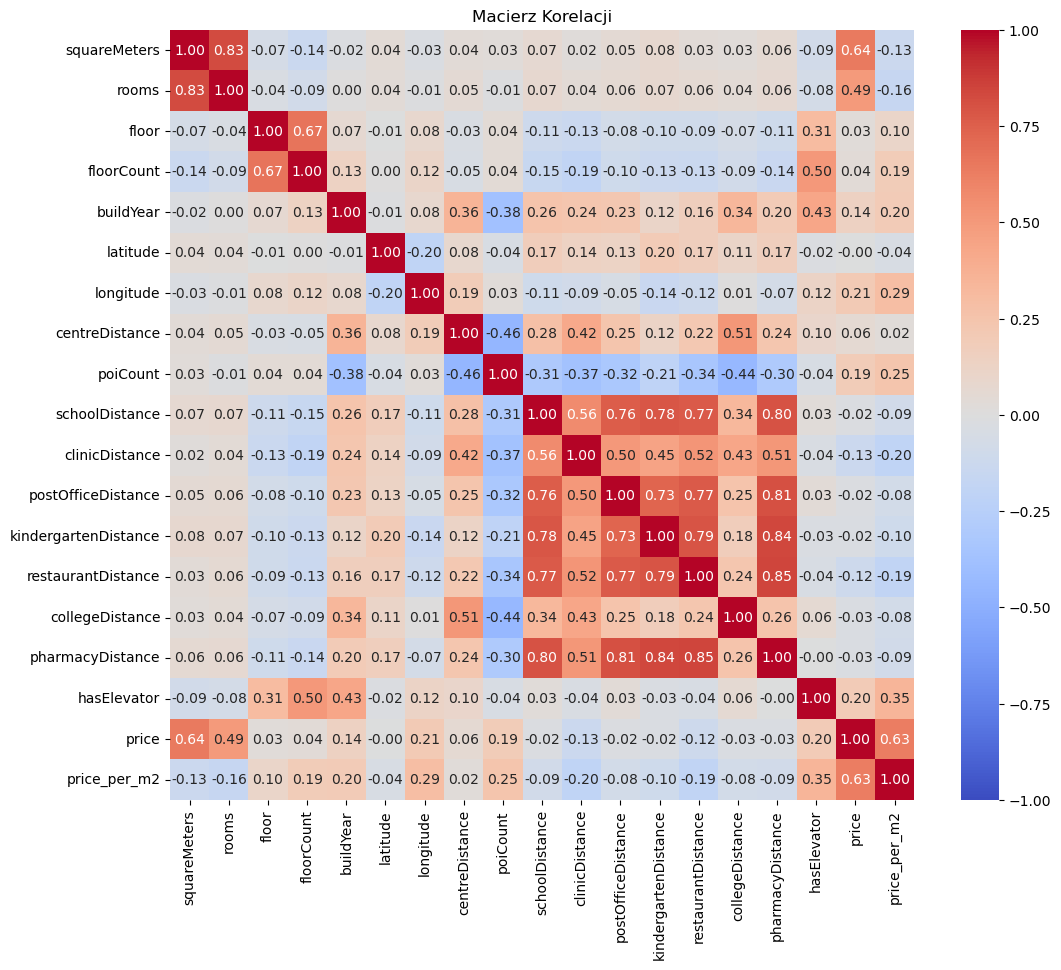

Co najbardziej podbija cenę za m2?
price_per_m2            1.000000
price                   0.626759
hasElevator             0.345644
longitude               0.294654
poiCount                0.248246
buildYear               0.202922
floorCount              0.189120
floor                   0.102843
centreDistance          0.024154
latitude               -0.042944
collegeDistance        -0.078206
postOfficeDistance     -0.083533
schoolDistance         -0.087365
pharmacyDistance       -0.091897
kindergartenDistance   -0.102017
squareMeters           -0.126340
rooms                  -0.160836
restaurantDistance     -0.193912
clinicDistance         -0.201326
Name: price_per_m2, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Wybieramy tylko kolumny liczbowe
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Obliczam korelację
correlation_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Macierz Korelacji")
plt.show()

print("Co najbardziej podbija cenę za m2?")
# Sortujemy korelacje względem ceny za m2
print(correlation_matrix['price_per_m2'].sort_values(ascending=False))

In [9]:
# Odrzucam te mało istotne (id) oraz te, które zdradzają odpowiedź (price - bo przewiduje cenę)
features = [
    'city', 'squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
    'latitude', 'longitude', 'centreDistance', 'poiCount', 'schoolDistance',
    'clinicDistance', 'pharmacyDistance', 'kindergartenDistance', 'restaurantDistance', 'condition', 'buildingMaterial',
    'hasElevator' # hasElevator to 0 lub 1, więc jest ok
]

X = df[features]
y = df['price'] # Target

# Zamiana miast na bool (One-Hot Encoding)
# Zmiana 'city' na 'city_Warszawa', 'city_Wroclaw' itd.
X = pd.get_dummies(X, columns=['city', 'condition', 'buildingMaterial'], dtype=int)

print("Gotowe dane do modelu")
print(f"Liczba kolumn po transformacji: {X.shape[1]}")
display(X.head())

Gotowe dane do modelu
Liczba kolumn po transformacji: 36


,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,...,city_rzeszow,city_szczecin,city_warszawa,city_wroclaw,condition_low,condition_premium,condition_unknown,buildingMaterial_brick,buildingMaterial_concreteSlab,buildingMaterial_unknown
0,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,6.53,9.0,0.118,...,0,1,0,0,0,0,1,0,1,0
5,63.30,3.0,2.0,4.0,1997.0,53.463100,14.572800,4.48,10.0,0.079,...,0,1,0,0,0,0,1,0,1,0
6,47.45,2.0,2.0,10.0,1974.0,53.450232,14.562625,2.99,18.0,0.327,...,0,1,0,0,1,0,0,0,1,0
7,60.08,2.0,3.0,4.0,2009.0,53.454685,14.551520,3.53,8.0,0.572,...,0,1,0,0,0,1,0,1,0,0
8,47.76,2.0,8.0,12.0,1980.0,53.458869,14.536403,4.27,6.0,0.345,...,0,1,0,0,0,0,1,0,1,0


## 4. Modelowanie (Machine Learning)
Używamy algorytmu **Random Forest Regressor**. Jest on odporny na nieliniowe zależności i dobrze radzi sobie z danymi kategorycznymi (po One-Hot Encodingu).

In [10]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")

Rozmiar zbioru treningowego: (108103, 36)
Rozmiar zbioru testowego: (27026, 36)


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Inicjalizacja modelu
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Średni błąd (MAE): {mae:.2f} PLN")
print(f"R2 Score: {r2:.4f}")

Średni błąd (MAE): 34853.49 PLN
R2 Score: 0.9717


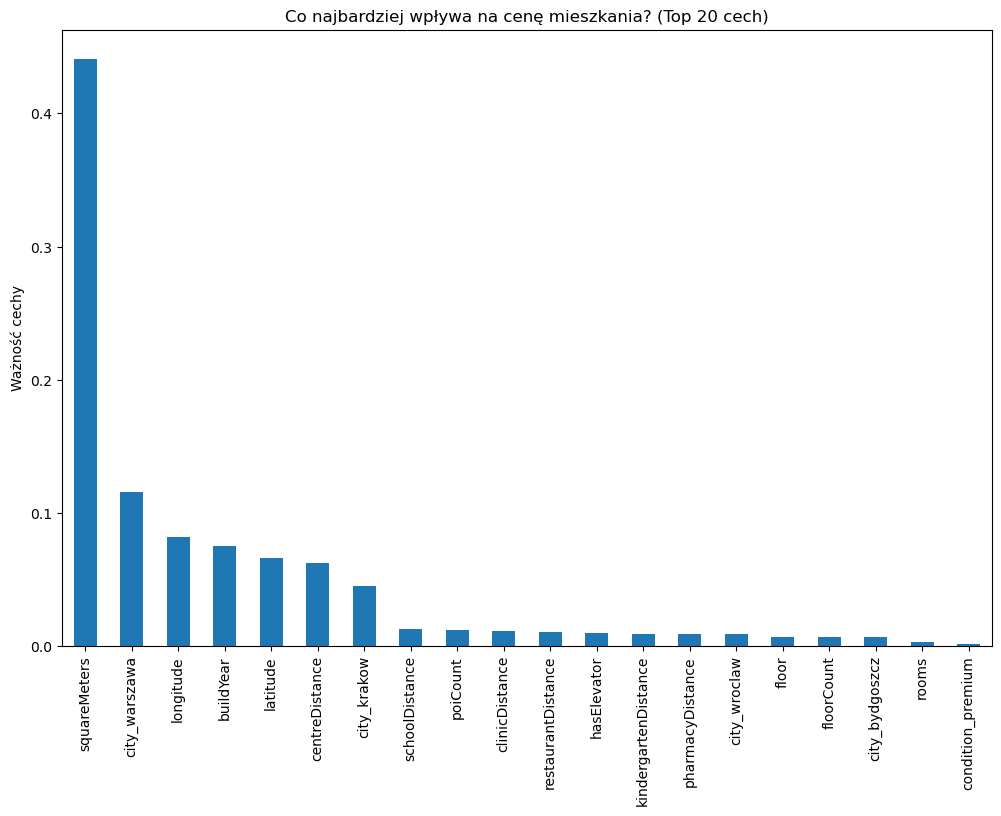

In [12]:
# Feature Importance
importances = model.feature_importances_
feature_names = X.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

# Wykres
plt.figure(figsize=(12, 8))
forest_importances.plot.bar()
plt.title("Co najbardziej wpływa na cenę mieszkania? (Top 20 cech)")
plt.ylabel("Ważność cechy")
plt.show()

## 5. Interpretowalność Modelu
Używamy biblioteki **SHAP**, aby zrozumieć, dlaczego model wycenił mieszkanie tak, a nie inaczej.
* Czerwone punkty = wysoka wartość cechy podwyższa cenę.
* Niebieskie punkty = niska wartość cechy obniża cenę.

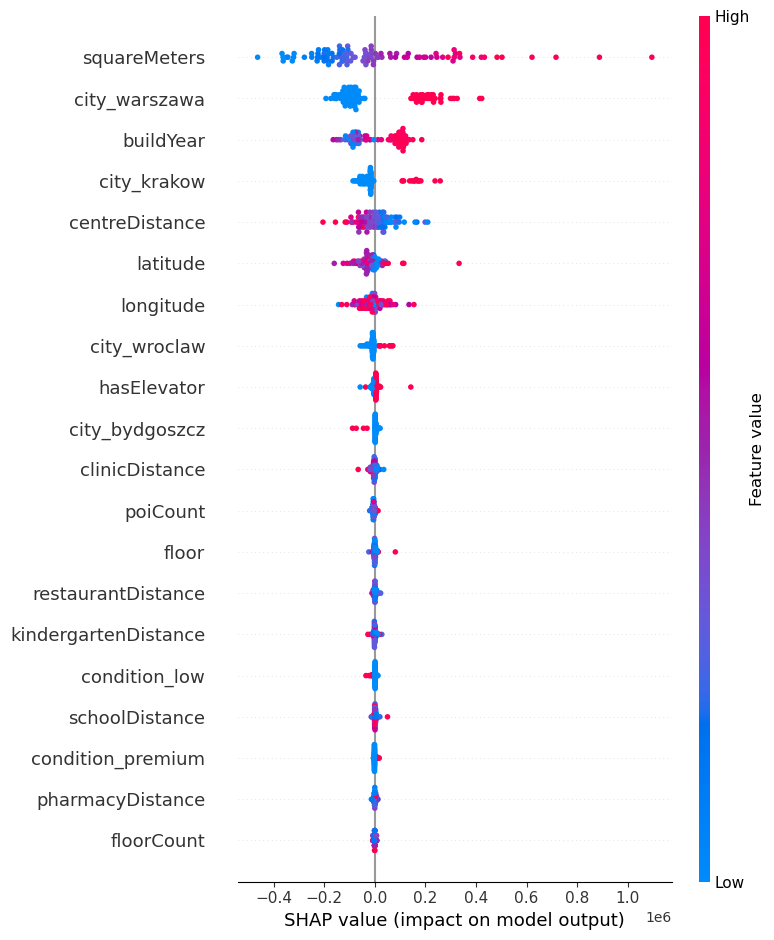

In [13]:
import shap

# Wyjaśnienie modelu
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:100]) # sample 100 mieszkań dla szybkości

# Wykres, który pokazuje co wpływa na cenę
shap.summary_plot(shap_values, X_test.iloc[:100])

## 6. Business Use-Case: Wyszukiwarka Okazji
Porównujemy cenę ofertową z wyceną naszego modelu.
* Jeśli `Cena Ofertowa < Wycena Modelu`, uznajemy to za potencjalną okazję inwestycyjną.

TOP 5 OKAZJI NA RYNKU:


,city,squareMeters,price,predicted_price,difference_pln
6676,gdansk,63.42,459000,9.689221e+05,509922.062784
24652,gdansk,63.42,459000,9.689221e+05,509922.062784
53244,gdynia,78.00,460000,9.407023e+05,480702.336270
55889,krakow,67.00,450000,8.941604e+05,444160.414141
70742,krakow,80.10,799000,1.585416e+06,786416.030505


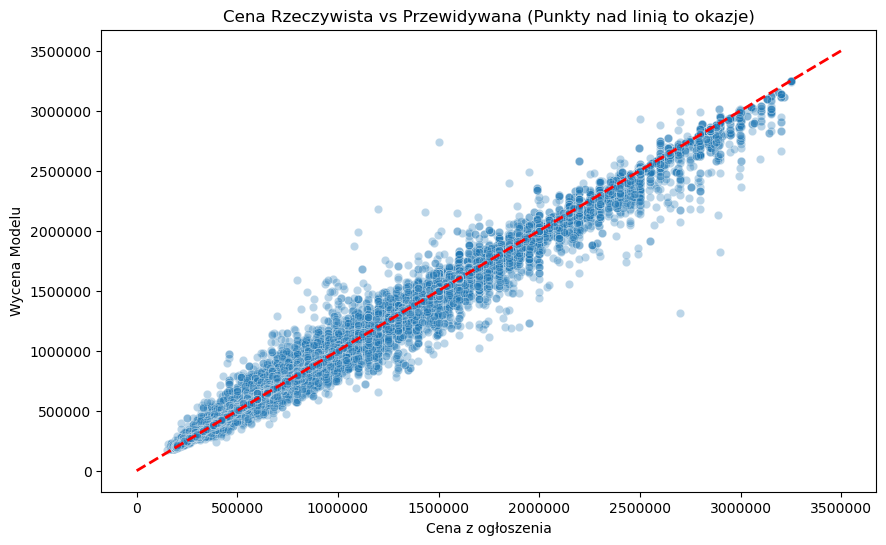

In [14]:
# WYKRYWANIE OKAZJI
all_predictions = model.predict(X)

analysis_df = df.copy()
analysis_df['predicted_price'] = all_predictions
analysis_df['difference_pln'] = analysis_df['predicted_price'] - analysis_df['price']
analysis_df['opportunity_score'] = analysis_df['difference_pln'] / analysis_df['predicted_price']

# Sortuje po % różnicy (model wycenił na 100%, cena to 70% -> mieszkanie jest niedowartościowane)
deals = analysis_df.sort_values(by='opportunity_score', ascending=False)

print("TOP 5 OKAZJI NA RYNKU:")
cols_show = ['city', 'squareMeters', 'price', 'predicted_price', 'difference_pln']
display(deals[cols_show].head(5))

# Sprawdzenie czy okazje to ruiny
plt.figure(figsize=(10, 6))
sns.scatterplot(data=analysis_df, x='price', y='predicted_price', alpha=0.3)
plt.plot([0, 3500000], [0, 3500000], 'r--', linewidth=2) # Linia idealna
plt.ticklabel_format(style='plain')
plt.title("Cena Rzeczywista vs Przewidywana (Punkty nad linią to okazje)")
plt.xlabel("Cena z ogłoszenia")
plt.ylabel("Wycena Modelu")
plt.show()

## 7. Wizualizacja Geograficzna
Najlepsze okazje nanosimy na interaktywną mapę.

In [15]:
import folium

# Tworzę mapę wyśrodkowaną na Polsce
m = folium.Map(location=[52.0, 19.0], zoom_start=6)

# TOP 50 okazji, żeby nie zamulić mapy
top_deals = deals.head(50)

for index, row in top_deals.iterrows():
    # Treść dymka po kliknięciu
    tooltip_text = f"{row['city']}, {row['squareMeters']}m2<br>Cena: {row['price']:,.0f} PLN<br>Okazja: {row['opportunity_score']:.1%}"
    
    folium.Marker(
        [row['latitude'], row['longitude']],
        popup=tooltip_text,
        tooltip="Kliknij, by zobaczyć okazję",
        icon=folium.Icon(color="green", icon="info-sign")
    ).add_to(m)

# Zamiast wyświetlać 'm' w notatniku, zapisujemy ją do pliku
m.save("mapa_okazji.html")

print("Mapa została zapisana jako plik 'mapa_okazji.html' w folderze projektu.")
print("Otwórz ten plik ręcznie w przeglądarce (Chrome/Edge), aby zobaczyć mapę.")

Mapa została zapisana jako plik 'mapa_okazji.html' w folderze projektu.
Otwórz ten plik ręcznie w przeglądarce (Chrome/Edge), aby zobaczyć mapę.


## 8. Eksport i Analiza SQL
Zapisujemy wyniki do bazy danych, aby móc wykonywać zapytania biznesowe (BI).

In [16]:
# EKSPORT DANYCH DO DALSZEJ ANALIZY
final_df = df.copy()
# 2. Dodaje kolumny z wynikami modelu
final_df['Predicted_Price'] = model.predict(X)  # Nasza wycena
final_df['Price_Diff'] = final_df['Predicted_Price'] - final_df['price'] # Różnica w PLN
final_df['Opportunity_Score'] = final_df['Price_Diff'] / final_df['Predicted_Price'] # Różnica w %

# 3. Oznaczamy okazje -> zysk powyżej 10%
final_df['Is_Deal'] = final_df['Opportunity_Score'] > 0.10

final_df.to_csv('apartments_final_with_predictions.csv', index=False)

print("Plik 'apartments_final_with_predictions.csv' został zapisany.")

Plik 'apartments_final_with_predictions.csv' został zapisany.
